In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import statsmodels.stats.multitest as multitest

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")

warm_gray = (190/255, 184/255, 177/255)
cool_gray = (119/255, 136/255, 153/255)
dual = ['#B9529F','gray']
triple = ['gray','Tab:red', 'Tab:blue']
ZD = {'Pre':'gray', 'Agg+': 'Tab:red', 'ZD7288': warm_gray}
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:red', 'Tab:blue','gray', 'Tab:red', 'gray']
six = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red']
seven = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red']
nine = ['gray', 'Tab:red', 'Tab:blue','gray', 'gray', 'Tab:red', 'Tab:red', 'Tab:red', 'Tab:red']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']
ant = ['Tab:red', 'Tab:red','Tab:red', 'Tab:red']

In [2]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (2, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                plt.xticks(rotation = 45)
                # ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                plt.ylabel(column.replace('_', ' '))

                sns.despine()
                
                plt.savefig(f'output_figures/{column}.png',
                    dpi=300,bbox_inches='tight', transparent=True)
                # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                #     dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(stat, p, dof)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# Ephys analysis

In [126]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)


cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Pre')] 
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Pre')]
       
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[(df.Gal_positive == 'Unknown') & (df.Behaviour_6hFD != 'Pre')]])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']

str_cols = ['Behaviour_6hFD', 'estrous_stage', 'Adaptive', 'I_zero', 'I_zero_reclassified', '60mV', 'cat_categ', 'Ih']
for col in str_cols:
       ephys[col] = ephys[col].apply(lambda x: str(x).strip() if isinstance(x, str) else x)
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [127]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [128]:
ephys_behav.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm_pF_', 'Adaptive',
       ...
       'Unnamed:_275', 'Unnamed:_276', 'Unnamed:_277', 'Unnamed:_278',
       'pup_intro', 'contact', 'attack', 'contact_latency', 'attack_latency',
       'attack_since_contact'],
      dtype='object', length=285)

In [129]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [130]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


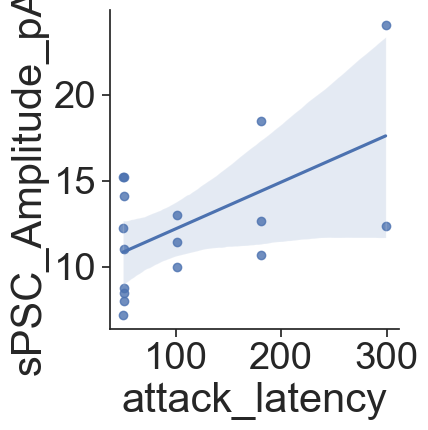

In [ ]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [132]:
ephys.Behaviour_6hFD.unique()


array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd', 'agrpkd'], dtype=object)

## All properties

In [133]:
filter_cat = ['Pre', 'Agg+', 'Agg-']

# # set categorical variables
# ephys['Behaviour_6hFD'] = pd.Categorical(ephys['Behaviour_6hFD'], categories=filter_cat, ordered=True)


# preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
#                 palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Tab:red', 'Tab:red', 'Gray'], order = filter_cat,
#                   plotting= True)


## Individual plots - panMPOA

In [134]:
# subset df for those groups needed for firing freq. plot
ephys2 = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+')]

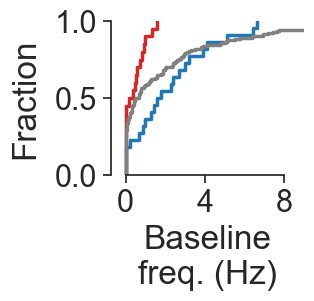

In [ ]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = triple_ff, linewidth=2.5, legend=False,
                   stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [136]:
# mouse and cell numbers
filtered = ephys2.dropna(subset=['Firing_freq_(Hz)_I0'])
mouse_counts = filtered.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
print(f"\033[1mMouse numbers:\033[0m\n \n{mouse_counts}") 
cell_counts = ephys2.groupby('Behaviour_6hFD')['Firing_freq_(Hz)_I0'].count()
print(f"\n\033[1mCell counts:\033[0m\n \n{cell_counts}")

Mouse numbers:
 
Behaviour_6hFD
Agg+     6
Agg-     3
Pre     24
Name: ID_mouse, dtype: int64

Cell counts:
 
Behaviour_6hFD
Agg+     20
Agg-     22
Pre     143
Name: Firing_freq_(Hz)_I0, dtype: int64


In [14]:
# Stats
ephys2_pre = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Pre', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_agg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg+', 'Firing_freq_(Hz)_I0'].dropna()
ephys2_noagg = ephys2.loc[ephys2['Behaviour_6hFD'] == 'Agg-', 'Firing_freq_(Hz)_I0'].dropna()

from scipy.stats import mannwhitneyu

# Pre vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg+:", p_value)
# Pre vs Agg-
u_statistic, p_value = mannwhitneyu(ephys2_pre, ephys2_noagg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Pre vs Agg-:", p_value)
# Agg- vs Agg+
u_statistic, p_value = mannwhitneyu(ephys2_noagg, ephys2_agg)
print("Mann-Whitney U Statistic:", u_statistic)
print("P-value Agg- vs Agg+:", p_value)

Mann-Whitney U Statistic: 1857.5
P-value Pre vs Agg+: 0.028797840159947314
Mann-Whitney U Statistic: 1252.0
P-value Pre vs Agg-: 0.1213247549769567
Mann-Whitney U Statistic: 352.5
P-value Agg- vs Agg+: 0.0007392103156646884


In [15]:
# stats - one-way ANOVA
from scipy.stats import f_oneway

filtered_groups = ['Pre', 'Agg+', 'Agg-']
ephys_filtered = ephys2[ephys2['Behaviour_6hFD'].isin(filtered_groups)]
ephys_filtered = ephys_filtered.dropna(subset=['Behaviour_6hFD', 'Firing_freq_(Hz)_I0'])
groups = ephys_filtered.groupby('Behaviour_6hFD')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result)

# Tukey HSD
tukey_results = pairwise_tukeyhsd(ephys_filtered['Firing_freq_(Hz)_I0'], ephys_filtered['Behaviour_6hFD'])
print(tukey_results)

One-way ANOVA p-value: F_onewayResult(statistic=3.1132005417313446, pvalue=0.04683465218150111)
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Agg+   Agg-   1.7918 0.0825 -0.1758 3.7594  False
  Agg+    Pre   1.5361 0.0471  0.0157 3.0565   True
  Agg-    Pre  -0.2557 0.9098 -1.7142 1.2028  False
---------------------------------------------------


In [16]:
# subset df for those groups needed for firing freq. plot - ALL GROUPS
ephys2_all = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg-') |(ephys['Behaviour_6hFD'] == 'Agg+') |
                      (ephys['Behaviour_6hFD'] == 'npy_antag') | (ephys['Behaviour_6hFD'] == 'npy_KD_dummy') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

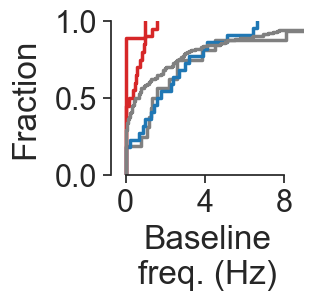

In [17]:
# Firing frequency - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys2_all, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = sixtus, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [18]:
# subset df for ZD
ephys2_zd = ephys.loc[(ephys['Behaviour_6hFD'] == 'Pre') | (ephys['Behaviour_6hFD'] == 'Agg+') |(ephys['Behaviour_6hFD'] == 'ZD7288')]

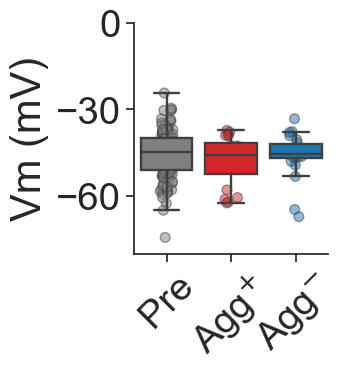

In [19]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [20]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd', 'agrpkd'], dtype=object)

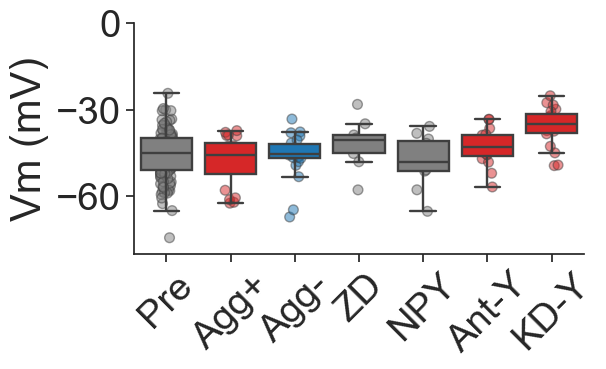

In [21]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [22]:
# ephys.Behaviour_6hFD.unique()

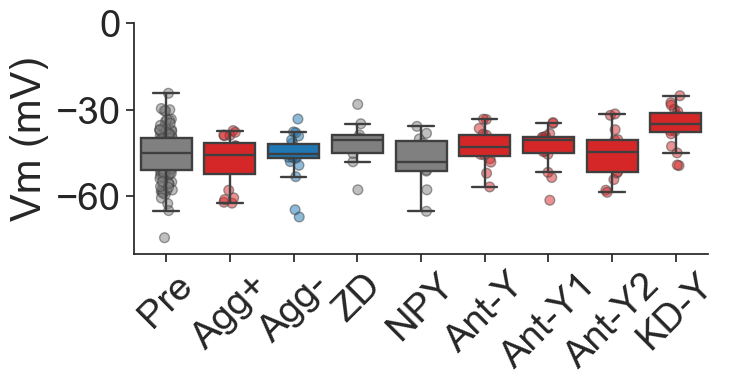

In [23]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS INCL. Y1/Y2 ANT

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','Ant-Y','Ant-Y1','Ant-Y2','KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

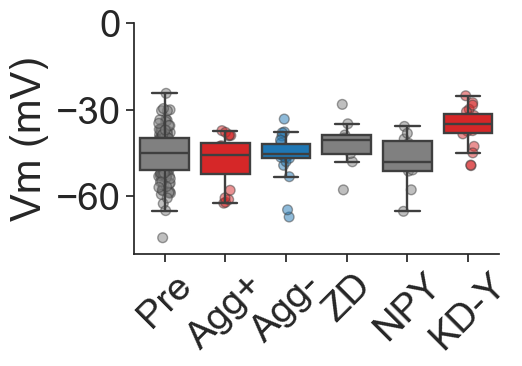

In [24]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS but w/o ANT

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = six)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = six, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD','NPY','KD-Y'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

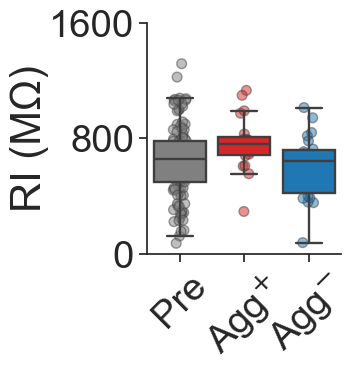

In [25]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [26]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Input_Resistance'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['Input_Resistance'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result)

all_input_resistances = np.concatenate([pre_group, agg_plus_group, agg_minus_group])
group_labels = ['Pre'] * len(pre_group) + ['Agg+'] * len(agg_plus_group) + ['Agg-'] * len(agg_minus_group)
tukey_results = pairwise_tukeyhsd(all_input_resistances, group_labels)
print(tukey_results)


One-way ANOVA p-value: F_onewayResult(statistic=2.6434744409148756, pvalue=0.07431886193709723)
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  Agg+   Agg- -160.9268 0.0767 -335.1058  13.2522  False
  Agg+    Pre -116.7093 0.1137 -254.2692  20.8505  False
  Agg-    Pre   44.2175 0.6976   -85.022 173.4569  False
--------------------------------------------------------


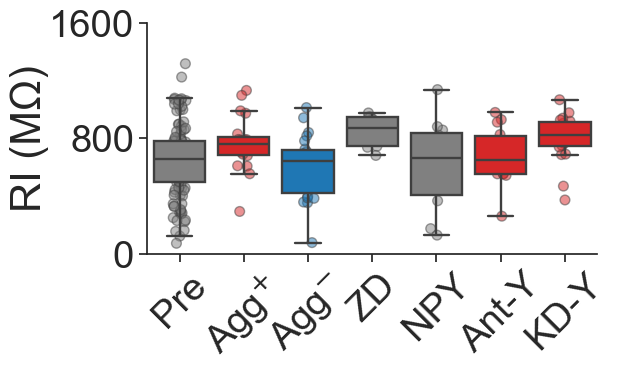

In [27]:
# Input resistance - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

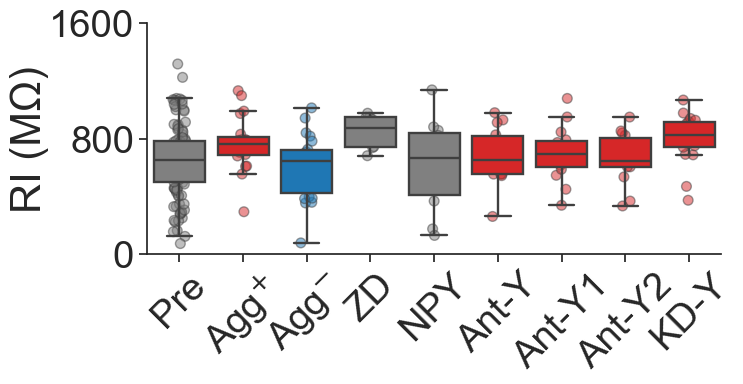

In [28]:
# Input resistance - VERSION WITH ALL GROUPS INCL Y1/2

sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = nine)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = nine, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' ,'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

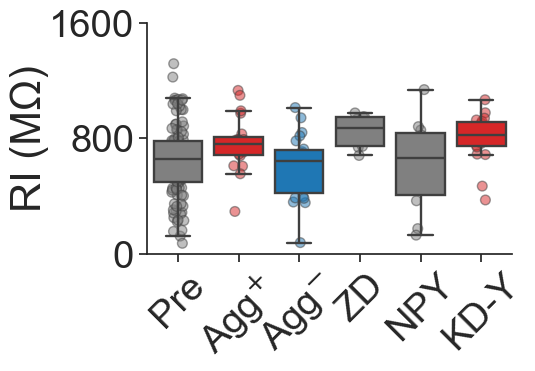

In [29]:
# Input resistance - VERSION WITH ALL GROUPS w/o Ant

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], 
                 saturation=8, linewidth=1.7, showfliers = False, palette = six)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'], 
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = six, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$', 'ZD', 'NPY' , 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [30]:
# STATS ====================================================================

# even though results are grouped in these plots, these are separate experiments, i.e. (1) Pre vs Agg- vs Agg+, (2) Pre vs ZD, Pre vs NPY,
# (3) Agg+ vs Ant-Y, (Agg+ vs Ant-Y1, Agg+ vs Ant-Y2), Agg+ vs KD-Y --> for (1) use ANOVA w/ Tukey; 
# for (2) and (3) use U test w/ Benjamini-Hochberg correction

# (1) ANOVA (Pre, Agg+, Agg-) ===============================================

group_summary = ephys.groupby('Behaviour_6hFD')['Input_Resistance'].agg(['count', 'var'])
# print(group_summary)

# filter for the groups we want
groups_to_include = ['Pre', 'Agg+', 'Agg-'] # , 'ZD7288', 'npy_100', 'npy_antag', 'npykd'
ephys3 = ephys[ephys['Behaviour_6hFD'].isin(groups_to_include)]

# Ensure 'Input_Resistance' is numeric and 'Behaviour_6hFD' is categorical
ephys3['Input_Resistance'] = pd.to_numeric(ephys3['Input_Resistance'], errors='coerce')
ephys3['Behaviour_6hFD'] = ephys3['Behaviour_6hFD'].astype('category')

# Drop rows with missing values
ephys3 = ephys3.dropna(subset=['Input_Resistance'])

# One-way ANOVA
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

if all(group_summary['count'] > 1) and all(group_summary['var'] > 0):
    anova_result = f_oneway(
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Pre'],
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Agg+'],
        ephys3['Input_Resistance'][ephys3['Behaviour_6hFD'] == 'Agg-']
    )

    print("One-way ANOVA p-value:", anova_result.pvalue)

    # Tukey HSD test for multiple comparisons
    tukey_results = pairwise_tukeyhsd(ephys3['Input_Resistance'], ephys3['Behaviour_6hFD'])
    print(tukey_results)
else:
    print("Not all groups have sufficient data or variance for ANOVA.")
    
# (2) U test: Pre vs ZD, Pre vs NPY ==========================================

group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
group_zd = ephys[ephys['Behaviour_6hFD'] == 'ZD7288']['Input_Resistance'].dropna()
group_npy = ephys[ephys['Behaviour_6hFD'] == 'npy_100']['Input_Resistance'].dropna()

u_statistic2, p_value2 = mannwhitneyu(group_pre, group_zd)
u_statistic3, p_value3 = mannwhitneyu(group_pre, group_npy)

# Benjamini-Hochberg correction
from statsmodels.stats.multitest import multipletests
p_values = [p_value2, p_value3]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Pre' and 'ZD7288': {p_value2}")
print(f"Mann-Whitney U test between 'Pre' and 'NPY': {p_value3}")
print("Corrected p-values:", p_adjusted)

# (3) U test: Agg+ vs Ant-Y, Agg+ vs Ant-Y1, Agg+ vs Ant-Y2, Agg+ vs KD-Y ==========================================

group_agg = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['Input_Resistance'].dropna()
group_ant = ephys[ephys['Behaviour_6hFD'] == 'npy_antag']['Input_Resistance'].dropna()
group_ant1 = ephys[ephys['Behaviour_6hFD'] == 'npy1r_antag']['Input_Resistance'].dropna()
group_ant2 = ephys[ephys['Behaviour_6hFD'] == 'npy2r_antag']['Input_Resistance'].dropna()
group_kd = ephys[ephys['Behaviour_6hFD'] == 'npykd']['Input_Resistance'].dropna()

u_statistic4, p_value4 = mannwhitneyu(group_agg, group_ant)
u_statistic5, p_value5 = mannwhitneyu(group_agg, group_ant1)
u_statistic6, p_value6 = mannwhitneyu(group_agg, group_ant2)
u_statistic7, p_value7 = mannwhitneyu(group_agg, group_kd)

p_values = [p_value4, p_value5, p_value6, p_value7]
reject, p_adjusted, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

print(f"\nMann-Whitney U test between 'Agg+' and 'Ant-Y': {p_value4}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y1': {p_value5}")
print(f"Mann-Whitney U test between 'Agg+' and 'Ant-Y2': {p_value6}")
print(f"Mann-Whitney U test between 'Agg+' and 'KD-Y': {p_value7}")
print("Corrected p-values:", p_adjusted)

One-way ANOVA p-value: 0.07431886193709723
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  Agg+   Agg- -160.9268 0.0767 -335.1058  13.2522  False
  Agg+    Pre -116.7093 0.1137 -254.2692  20.8505  False
  Agg-    Pre   44.2175 0.6976   -85.022 173.4569  False
--------------------------------------------------------

Mann-Whitney U test between 'Pre' and 'ZD7288': 0.004354252359002205
Mann-Whitney U test between 'Pre' and 'NPY': 0.7921242740088735
Corrected p-values: [0.0087085  0.79212427]

Mann-Whitney U test between 'Agg+' and 'Ant-Y': 0.17194793289971422
Mann-Whitney U test between 'Agg+' and 'Ant-Y1': 0.25238104262144023
Mann-Whitney U test between 'Agg+' and 'Ant-Y2': 0.14011244626592897
Mann-Whitney U test between 'Agg+' and 'KD-Y': 0.30686792369038496
Corrected p-values: [0.30686792 0.30686792 0.30686792 0.30686792]


In [31]:
# cell numbers
group_counts = ephys['Behaviour_6hFD'].value_counts()
# print(group_counts)
# mice per group
unique_id_counts = ephys.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
# print(unique_id_counts)

In [32]:
ephys.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm(pF)', 'Adaptive',
       ...
       'Unnamed: 269', 'Unnamed: 270', 'Unnamed: 271', 'Unnamed: 272',
       'Unnamed: 273', 'Unnamed: 274', 'Unnamed: 275', 'Unnamed: 276',
       'Unnamed: 277', 'Unnamed: 278'],
      dtype='object', length=279)

In [ ]:
for variable in ls:
    
    subset_df = ephys[ephys['Behaviour_6hFD'].isin(['Agg+', 'npykd'])]
    print(variable)
    try:
        print(stats.mannwhitneyu(subset_df[subset_df['Behaviour_6hFD'] == 'Agg+'][variable].dropna(), 
                                subset_df[subset_df['Behaviour_6hFD'] == 'npykd'][variable].dropna()))
    except Exception as e:
        print(f"Error processing {variable}: {e}")
        continue

Cm(pF)
Error processing Cm(pF): `x` and `y` must be of nonzero size.
Firing_freq_(Hz)_I0
MannwhitneyuResult(statistic=112.5, pvalue=0.026735672074107823)
Instant_freq_(Hz)
MannwhitneyuResult(statistic=115.5, pvalue=0.03308260548978594)
isi_(ms)
MannwhitneyuResult(statistic=195.5, pvalue=0.8856276130821868)
CaT
MannwhitneyuResult(statistic=185.0, pvalue=0.880181579041291)
Ih_at_-120mV
MannwhitneyuResult(statistic=103.0, pvalue=0.023913065919995057)
AP_ampl
MannwhitneyuResult(statistic=189.5, pvalue=1.0)
AP_halfwidth
Error processing AP_halfwidth: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
AP_time_to_peak
MannwhitneyuResult(statistic=130.5, pvalue=0.08960591120417029)
area(mV_ms)
MannwhitneyuResult(statistic=170.5, pvalue=0.5846617026404489)
rheobase_at_-60mV_(pA)
MannwhitneyuResult(statistic=168.5, pvalue=0.9513460710428313)
AHP_(mV)
MannwhitneyuResult(statistic=153.5, pvalue=0

In [35]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd', 'agrpkd'], dtype=object)

In [41]:
for variable in ls:
    variable = variable
    formula = f'Q("{variable}") ~ C(estrous_stage)'
    subset_df = ephys[ephys['Behaviour_6hFD'].isin(['Pre'])]
    subset_df[variable] = pd.to_numeric(subset_df[variable], errors='coerce')
    model = smf.ols(formula, data=subset_df).fit()
    anova_results = sm.stats.anova_lm(model, typ=2)
    print(variable, anova_results)

Cm(pF)                         sum_sq    df          F        PR(>F)
C(estrous_stage)  66563.358683   9.0  39.487782  1.078644e-09
Residual           3745.932760  20.0        NaN           NaN
Firing_freq_(Hz)_I0                        sum_sq     df         F    PR(>F)
C(estrous_stage)    41.179662    9.0  0.510674  0.864799
Residual          1191.647759  133.0       NaN       NaN
Instant_freq_(Hz)                        sum_sq     df         F    PR(>F)
C(estrous_stage)    52.086958    9.0  0.611546  0.785539
Residual          1258.661172  133.0       NaN       NaN
isi_(ms)                         sum_sq     df         F    PR(>F)
C(estrous_stage)  3.990666e+08    9.0  0.700671  0.707346
Residual          8.353385e+09  132.0       NaN       NaN
CaT                        sum_sq     df         F    PR(>F)
C(estrous_stage)   985.236537    9.0  1.217194  0.295866
Residual          9713.188912  108.0       NaN       NaN
Ih_at_-120mV                        sum_sq     df        F    PR(>F)


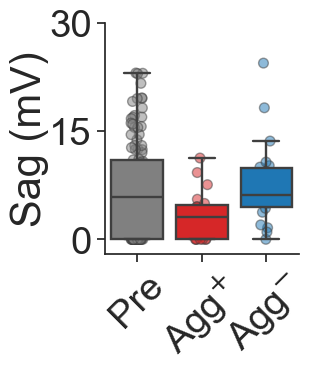

In [42]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order = ['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

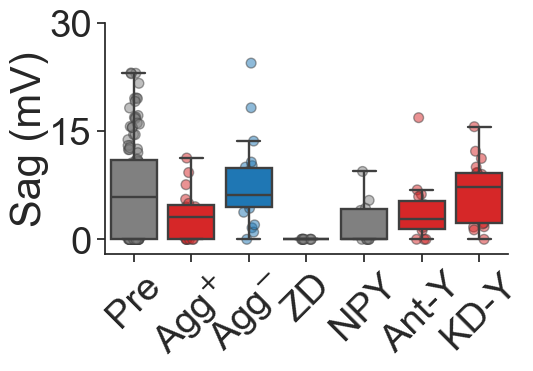

In [43]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y', 'KD-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

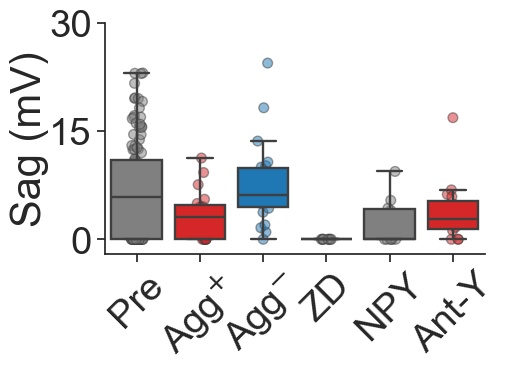

In [44]:
# Ih - VERSION without KD-Y
sns.set(rc={"figure.figsize": (4.9, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = seven)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = seven, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY','Ant-Y'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_noKD.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

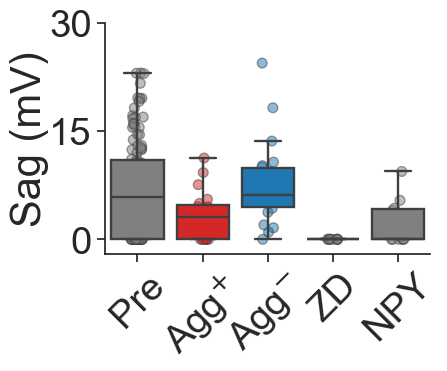

In [45]:
# Ih - VERSION without KD-Y and Ant-Y
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = six)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = six, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$','ZD','NPY'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_noKD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

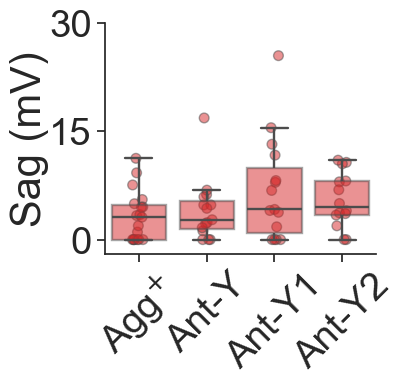

In [46]:
# Ih - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (3.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=[ 'Agg+','npy_antag', 'npy1r_antag', 'npy2r_antag'],
                 saturation=8, linewidth=1.7, showfliers = False, palette = ['Tab:red'], boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys, order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'],
                   jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = ['Tab:red'], alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ( r'Agg$^{+}$', 'Ant-Y','Ant-Y1','Ant-Y2' ), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)


    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

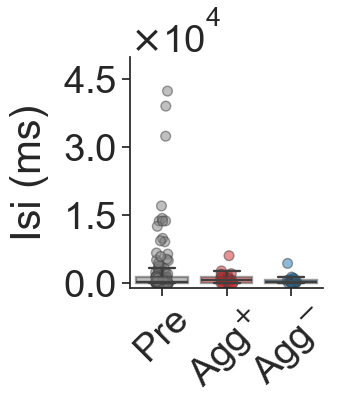

In [47]:
# Isi
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='isi_(ms)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='isi_(ms)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Isi (ms)', labelpad=10)

# Set the y-axis to be in scientific notation
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# Use scientific notation for ticks
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(-1000, 50000)
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/isi.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

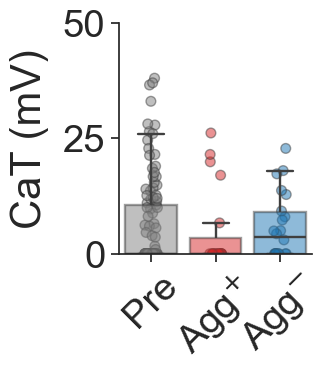

In [48]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='CaT', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('CaT (mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)


    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [49]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['CaT'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['CaT'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['CaT'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.9002218488654643


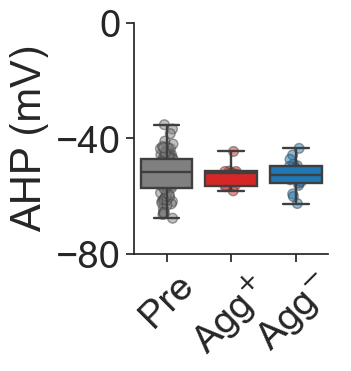

In [50]:
# AHP

ephys_filtered = ephys[ephys['AHP_(mV)'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple)
ax = sns.stripplot(x='Behaviour_6hFD', y='AHP_(mV)', data = ephys_filtered, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = triple, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('AHP (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

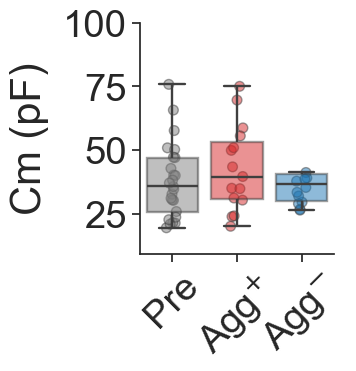

In [51]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Cm(pF)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

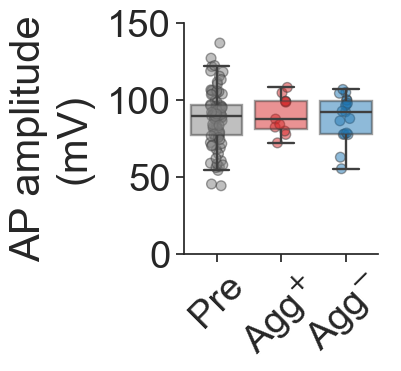

In [52]:
# AP_ampl
ephys_filt = ephys[ephys['AP_ampl'] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_ampl', data = ephys_filt, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP amplitude\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
plt.ylim(0,150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

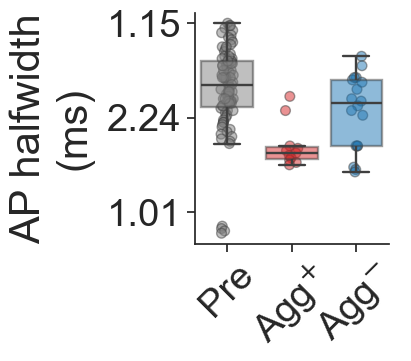

In [53]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")
non_silent = ephys[ephys.I_zero != 'silent']

ax = sns.boxplot(x='Behaviour_6hFD', y='AP_halfwidth', data = non_silent, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='AP_halfwidth', data = non_silent, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP halfwidth\n(ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [54]:
# stats - ANOVA + Tukey
pre_group = ephys[ephys['Behaviour_6hFD'] == 'Pre']['AP_halfwidth'].dropna()
agg_plus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg+']['AP_halfwidth'].dropna()
agg_minus_group = ephys[ephys['Behaviour_6hFD'] == 'Agg-']['AP_halfwidth'].dropna()

anova_result = f_oneway(pre_group, agg_plus_group, agg_minus_group)
print("One-way ANOVA p-value:", anova_result.pvalue)

One-way ANOVA p-value: 0.8060194877133406


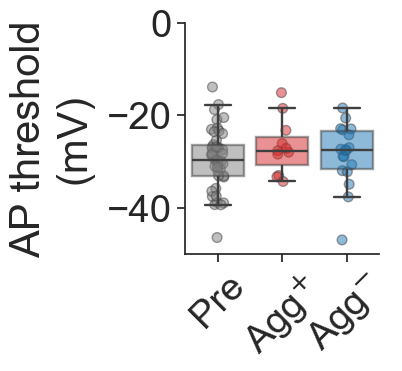

In [55]:
# AP threshold - loaded from a different excel sheet currently, but will add to main ephys.csv file
ap_thresh = pd.read_csv('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/AP threshold/APthreshold_v1.csv')

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple,boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='state', y='AP_threshold_mV', data = ap_thresh, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('AP threshold\n(mV)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-50, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_threshold.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [56]:
response_var = 'state'
formula = f'AP_threshold_mV ~ Q("{response_var}")'
model = smf.ols(formula, data=ap_thresh).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)

                 sum_sq    df         F    PR(>F)
Q("state")    60.676972   2.0  0.722006  0.489308
Residual    2983.398255  71.0       NaN       NaN


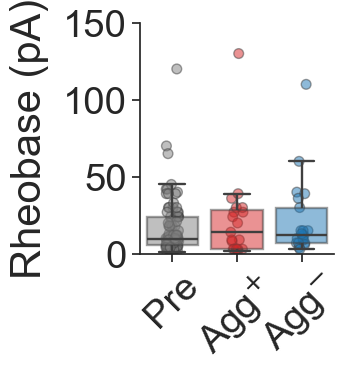

In [57]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple,boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='rheobase_at_-60mV_(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('Rheobase (pA)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

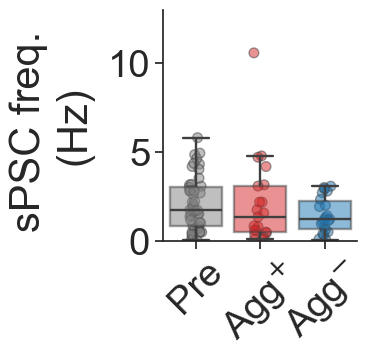

In [58]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple,boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_frequency', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC freq. \n(Hz)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,13)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

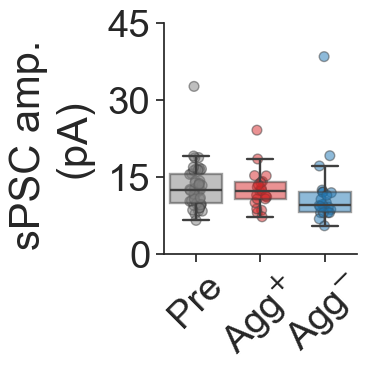

In [59]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple,boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSC_Amplitude(pA)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. \n(pA)', labelpad=10)

ax.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

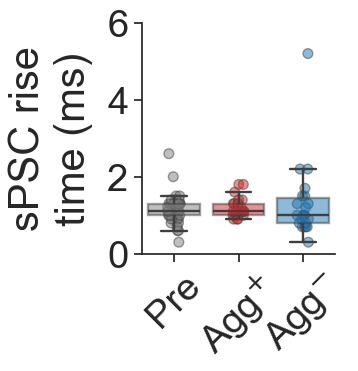

In [60]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple,boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs_Rise time', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC rise\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

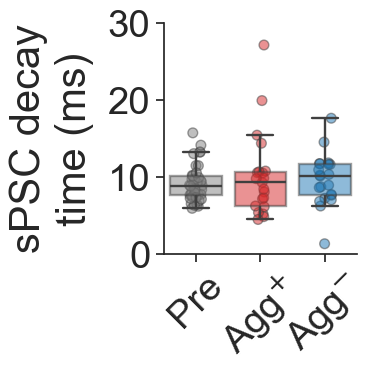

In [61]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")


ax = sns.boxplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = triple,boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='sPSCs (decay)', data = ephys, order=['Pre', 'Agg+', 'Agg-'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = triple)
ax.set_xlabel('')
ax.set_ylabel('sPSC decay\ntime (ms)', labelpad=10)

ax.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0,30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Gal+ vs Gal-

In [62]:
# gal = ephys[(ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# no_gal = ephys[(ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')]
# gals = pd.concat([gal,no_gal], axis = 0)
# len(no_gal)

In [63]:
# count_yes_agg = ((ephys['Gal_positive'] == 'yes') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# count_no_agg = ((ephys['Gal_positive'] == 'no') & (ephys['Behaviour_6hFD'] == 'Agg+')).sum()
# print(f"Number of Gal+ (Agg+) cells: {count_yes_agg}")
# print(f"Number of Gal- (Agg+) cells: {count_no_agg}")

In [ ]:
# preprocess_plot(ephys[(ephys.Gal_positive.isin(['no', 'yes'])) & (ephys.Behaviour_6hFD.isin(['Agg-', 'Agg+']))], 
#                 'Gal_positive', 'gal', palette=['Gray', 'Tab:red'], order = ['no', 'yes'], plotting= True)

In [65]:
# correlation between input resistance and Sag
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,2.645382e+05,1.0,4.706788,0.03212
Residual,6.407203e+06,114.0,NaN,NaN


In [66]:
trial.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm(pF)', 'Adaptive',
       ...
       'Unnamed: 269', 'Unnamed: 270', 'Unnamed: 271', 'Unnamed: 272',
       'Unnamed: 273', 'Unnamed: 274', 'Unnamed: 275', 'Unnamed: 276',
       'Unnamed: 277', 'Unnamed: 278'],
      dtype='object', length=279)

In [67]:
# Correlation between Sag and firing freq

model = smf.ols('firing_freq ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,0.310982,1.0,0.032309,0.857665
Residual,1116.536029,116.0,NaN,NaN


In [68]:
print("Coefficient of determination (R^2):", model.rsquared)

Coefficient of determination (R^2): 0.00027844636083884655


In [69]:
# sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
# plt.xlabel('Ih current (pA)')
# plt.ylabel('Input resistance (MΩ)')
# plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')

(-1.0, 24.0)

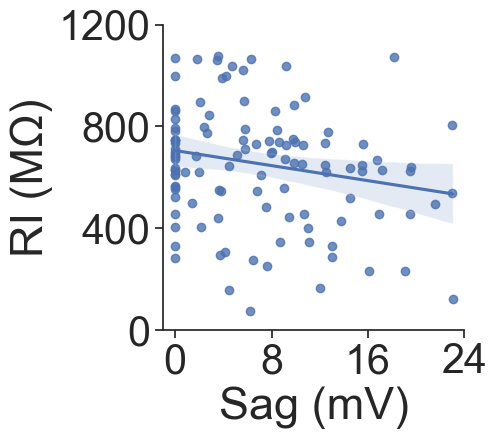

In [ ]:
sns.set(font_scale=2.7) 
sns.set_style("ticks")
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'], aspect=1.1)
plt.ylabel('RI (MΩ)')
plt.xlabel('Sag (mV)')
plt.ylim(0, 1200)
plt.yticks([0, 400, 800, 1200])
plt.xticks([0, 8, 16, 24])
plt.xlim(-1, 24)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ih_input_resistance.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [71]:
prop = 'sPSC_frequency'
# conduct U test
group_pre = ephys[ephys['Behaviour_6hFD'] == 'Pre'][prop].dropna()
group_ZD = ephys[ephys['Behaviour_6hFD'] == 'ZD7288'][prop].dropna()

# import Mann-Whitney U test
from scipy.stats import mannwhitneyu

u_statistic, p_value = mannwhitneyu(group_pre, group_ZD)
print(p_value)


6.656721418097667e-05


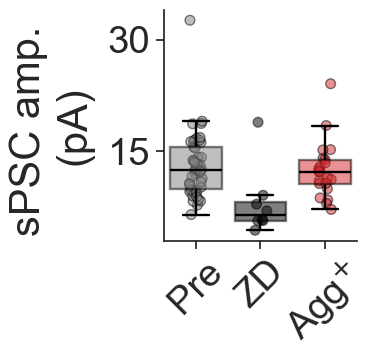

In [ ]:
# l = 'Instant_freq_(Hz)'
# max = ephys[l].max()
# cs = ['darkgray', '#F97306', 'Tab:blue']
# conds = ['Pre', 'Agg+', 'Agg-']
# fig, ax = plt.subplots(figsize=(2, 2))
# sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
# sns.despine()
# plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(style="ticks", font_scale=2.5)
prop = 'sPSC_Amplitude(pA)'

ax = sns.boxplot(x='Behaviour_6hFD', y=prop, data = ephys, order=['Pre', 'ZD7288', 'Agg+'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['gray', 'black', 'Tab:red'], boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y=prop, data = ephys, order=['Pre', 'ZD7288', 'Agg+'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', alpha=0.5, zorder=0, palette = ['gray', 'black', 'Tab:red'])
ax.set_xlabel('')
ax.set_ylabel('sPSC amp. \n(pA)', labelpad=10)

ax.set_xticklabels( ('Pre', 'ZD', r'Agg$^{+}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0,30)
sns.despine(bottom=False, trim=False)
plt.savefig(f'/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/{prop}_ZD.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


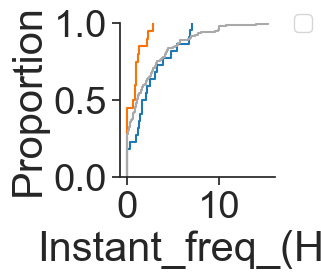

In [74]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

# plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

### Individual plots Gal+ vs Gal-

In [75]:
gals = df[(df.Gal_positive.isin(['yes', 'no'])) & (df.Behaviour_6hFD != 'Pre')]

In [76]:
print(f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice")
print(f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice")

Number of Gal+ neurons: 9 from 3 mice
Number of Gal- neurons: 10 from 4 mice


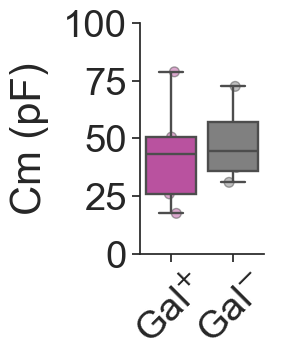

In [ ]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

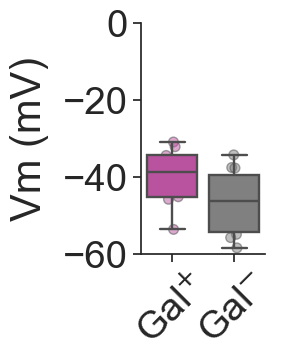

In [ ]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [79]:
# stats - U test
gal_positive_data = gals[gals['Gal_positive'] == 'yes']['Vm']
gal_negative_data = gals[gals['Gal_positive'] == 'no']['Vm']
u_statistic, p_value = mannwhitneyu(gal_positive_data, gal_negative_data)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.11134688653314041


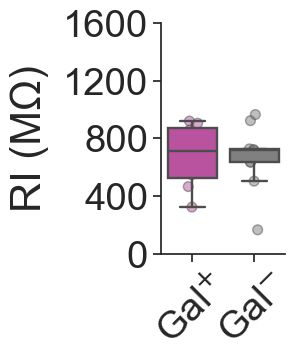

In [ ]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

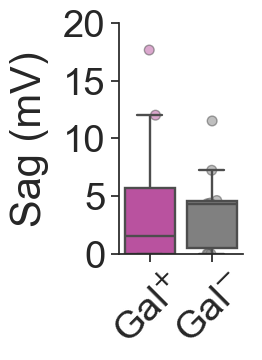

In [ ]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [82]:
# stats - U test
gal_positive_sag = gals[gals['Gal_positive'] == 'yes']['Input_Resistance'].dropna()
gal_negative_sag = gals[gals['Gal_positive'] == 'no']['Input_Resistance'].dropna()
u_statistic, p_value = mannwhitneyu(gal_positive_sag, gal_negative_sag)
print("Mann-Whitney U test p-value:", u_statistic, p_value)

Mann-Whitney U test p-value: 36.0 1.0


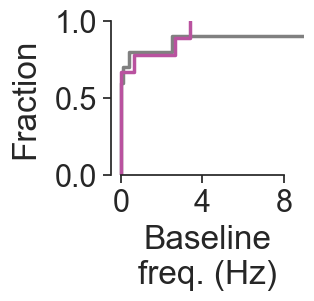

In [ ]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## Silent proportion

In [102]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd', 'agrpkd'], dtype=object)

In [ ]:
## silent proportion
cols = ['silent']
cat = ['Pre', 'Agg+', 'Agg-', "ZD7288", "npy_antag", "npy1r_antag", "npy2r_antag", "npy_antag", 'npykd', 'agrpkd', 'npy_100']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
# plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

I_zero_reclassified  phasic  silent  silent   tonic  tonic   All
Behaviour_6hFD                                                  
Agg+                      6       9        0      5       0   20
Agg-                      4       4        0     14       0   22
Pre                      26      38        1     76       3  144
ZD7288                    0       8        0      1       0    9
agrpkd                    2       3        0     17       0   22
npy1r_antag               2       3        0     10       0   15
npy2r_antag               3       6        0      6       0   15
npy_100                   2       7        0      2       0   11
npy_antag                 4       3        0      9       0   16
npykd                     3       5        0     11       0   19
All                      52      86        1    151       3  293
43.67785460912487 0.17751850159203836 36


ValueError: Categorical categories must be unique

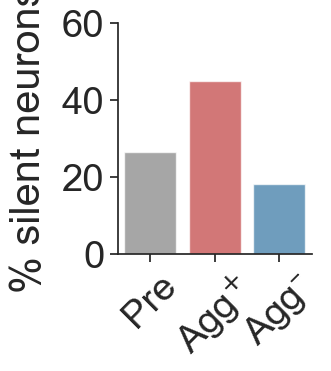

In [ ]:
# % silent neurons
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'], palette = triple, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{–}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine(bottom=False)
# g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [105]:
silent_df = silent_prop.loc[:, ['Behaviour_6hFD', 'silent']]

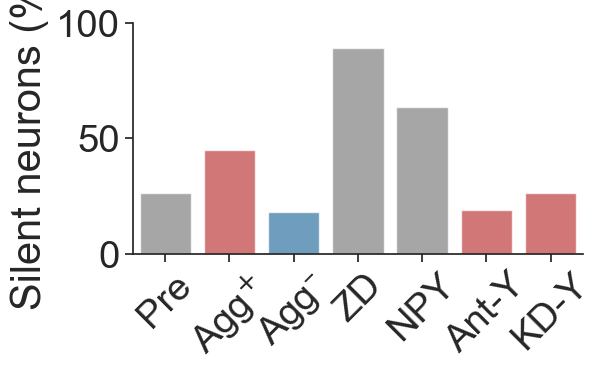

In [106]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npykd'],
                palette = seven, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

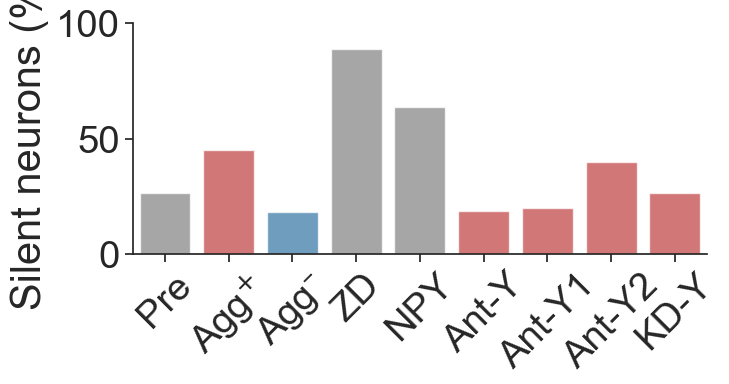

In [107]:
# % silent neurons - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd'],
                palette = nine, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'Ant-Y','Ant-Y1','Ant-Y2', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

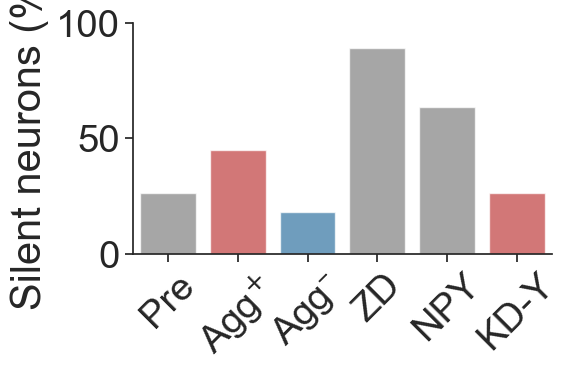

In [108]:
# % silent neurons - VERSION WITH ALL GROUPS but w/o Ant
sns.set(rc={"figure.figsize": (5.4, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")


g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npykd'],
                palette = six, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$','ZD', 'NPY', 'KD-Y'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)


plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
dpi=300,bbox_inches='tight', transparent=True, pad_inches=0.5)

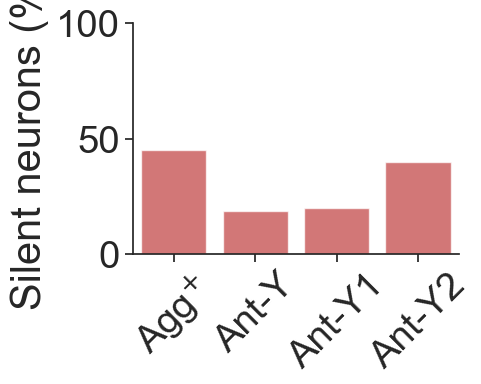

In [109]:
# % silent neurons - VERSION WITH ONLY ANT
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Agg+', 'npy_antag', 'npy1r_antag', 'npy2r_antag'],
                palette = ant, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( (r'Agg$^{+}$', 'Ant-Y','Ant-Y1','Ant-Y2'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ant.pdf',
dpi=300,bbox_inches='tight', transparent=True, pad_inches=0.5)

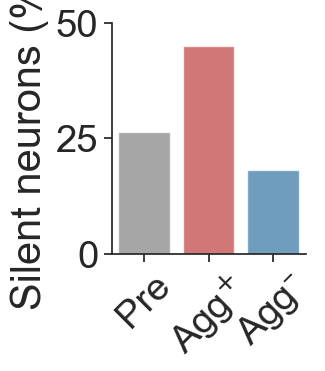

In [110]:
# % silent neurons - only Pre/Agg+/Agg-
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-'],
                palette = triple, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', r'Agg$^{+}$', r'Agg$^{–}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,50)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_short.pdf',
dpi=300,bbox_inches='tight', transparent=True)

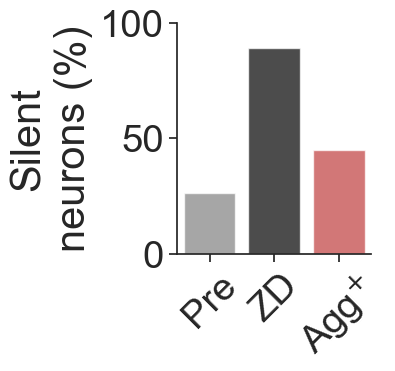

In [111]:
# % silent neurons - Pre/Agg+/ZD
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Behaviour_6hFD", y="silent", order=['Pre', 'ZD7288', 'Agg+'],
                palette = ['gray', 'black', 'Tab:red'], alpha=0.7)
plt.ylabel('Silent\nneurons (%)', labelpad=5)
g.set_xticklabels( ('Pre', 'ZD', r'Agg$^{+}$'), rotation=45)
plt.xlabel('')
plt.ylim(0,100)
g.yaxis.set_major_locator(plt.MaxNLocator(2)) 
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ZD.pdf',
dpi=300,bbox_inches='tight', transparent=True)

In [112]:
# mouse numbers
filtered = ephys.dropna(subset=['I_zero_reclassified'])
mouse_counts = filtered.groupby('Behaviour_6hFD')['ID_mouse'].nunique()
mouse_counts

Behaviour_6hFD
Agg+               6
Agg-               3
Pre               24
ZD7288             1
ZD7288_20          1
agrp_100           5
agrpkd             4
npy1r_antag        2
npy2r_antag        3
npy_10             3
npy_100            4
npy_100_paired     1
npy_10_paired      0
npy_antag          3
npykd              3
Name: ID_mouse, dtype: int64

In [113]:
# stats
# make contingency table (based on ephys df, not silent_prop, which only has %)
ephys2 = ephys.copy()
ephys2['I_zero_reclassified'] = ephys2['I_zero_reclassified'].replace({'phasic': 'active', 'tonic': 'active'})
contingency_table = ephys2.groupby(['Behaviour_6hFD', 'I_zero_reclassified']).size().unstack(fill_value=0)
contingency_table['active'] = contingency_table.sum(axis=1) - contingency_table.get('silent', 0)
contingency_table = contingency_table[['silent', 'active']]
print(contingency_table)

# groups = ['Agg+','Agg-','Pre','ZD7288','npy_100','npy_antag','npykd'] #'npy1r_antag','npy2r_antag',

# (1) Pre/Agg+/Agg- ==================================

groups = ['Agg+','Agg-','Pre']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")


# (2) Pre/ZD/NPY ==================================

groups = ['Pre', 'ZD7288', 'npy_100']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")

# (3) Agg+/Ant-Y/KD-Y ==================================

groups = ['Agg+', 'npy_antag', 'npykd']
p_values = []
comparisons = []
from scipy.stats import fisher_exact

# Perform Fisher's exact test between each pair of groups
for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        
        # Create contingency table
        table = [
            [contingency_table.loc[group1, 'silent'], contingency_table.loc[group1, 'active']],
            [contingency_table.loc[group2, 'silent'], contingency_table.loc[group2, 'active']]
        ]
        
        # Perform Fisher's exact test
        _, p_value = fisher_exact(table)
        
        # Store the p-value and the comparison
        p_values.append(p_value)
        comparisons.append(f"{group1} vs {group2}")

# Apply Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Print the results
for comp, pval, pval_corr in zip(comparisons, p_values, pvals_corrected):
    print(f"Comparison: {comp}, Original p-value: {pval:.4e}, Corrected p-value: {pval_corr:.4e}")

I_zero_reclassified  silent  active
Behaviour_6hFD                     
Agg+                      9      11
Agg-                      4      18
Pre                      38     106
ZD7288                    8       1
ZD7288_20                 5       0
agrp_100                  5      10
agrpkd                    3      19
npy1r_antag               3      12
npy2r_antag               6       9
npy_10                    2       8
npy_100                   7       4
npy_100_paired            4       0
npy_10_paired             5       1
npy_antag                 3      13
npykd                     5      14
Comparison: Agg+ vs Agg-, Original p-value: 9.5594e-02, Corrected p-value: 1.6820e-01
Comparison: Agg+ vs Pre, Original p-value: 1.1213e-01, Corrected p-value: 1.6820e-01
Comparison: Agg- vs Pre, Original p-value: 5.9899e-01, Corrected p-value: 5.9899e-01
Comparison: Pre vs ZD7288, Original p-value: 2.9134e-04, Corrected p-value: 8.7401e-04
Comparison: Pre vs npy_100, Original p-value:

In [ ]:
# % silent neurons CHECK WHETHER THESE VALUES ARE CORRECT!

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
# plt.savefig('output_figures/silent_prop.pdf',dpi = 300, bbox_inches = 'tight')

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       6      4   10
yes                1       6      2    9
All                1      12      6   19
1.6185185185185187 0.44518771279268876 2


Text(0.5, 1.0, 'galanin_silent_prop')

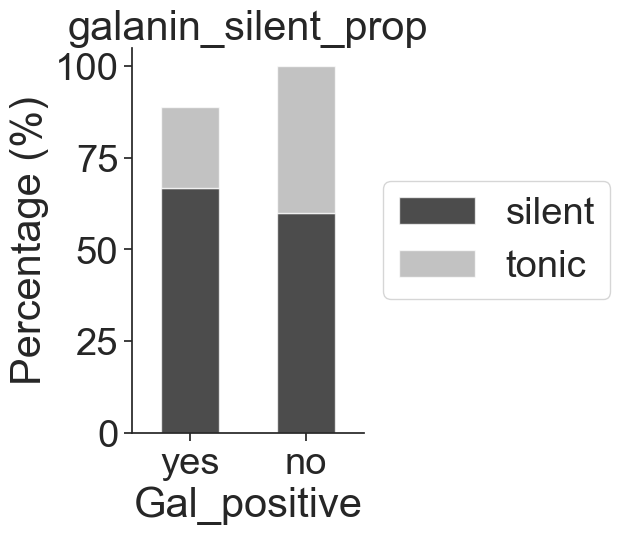

In [ ]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
# plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

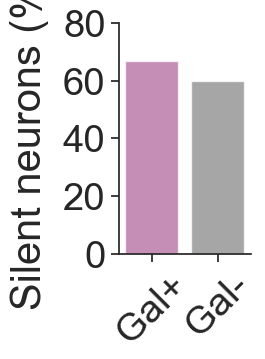

In [117]:
# % silent neurons
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_prop, x="Gal_positive", y="silent", order=['yes', 'no'], palette = dual, alpha=0.7)
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Gal+', 'Gal-'), rotation=45)
plt.xlabel('')
plt.ylim(0,80)
g.yaxis.set_major_locator(plt.MaxNLocator(4)) 
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/silent.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

## Adaptive prop (DB)

In [118]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100','npy_antag', 'npy1r_antag', 'npy2r_antag','npykd']
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
# ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
# ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])
# ad_prop

Adaptive        ?  no  no   yes  All
Behaviour_6hFD                      
Agg+            1   7    0   12   20
Agg-            0  18    0    3   21
Pre             1  25    0   32   58
ZD7288          1   0    0    8    9
npy1r_antag     0   9    0    6   15
npy2r_antag     0  10    0    4   14
npy_100         0   7    0    2    9
npy_antag       0   5    0    5   10
npykd           0   9    1    9   19
All             3  90    1   81  175
41.67245455948655 0.014037973671981098 24


In [119]:
ad_prop

Adaptive,Behaviour_6hFD,yes,no
0,Agg+,60.000000,35.000000
1,Agg-,14.285714,85.714286
2,Pre,55.172414,43.103448
3,ZD7288,88.888889,0.000000
4,npy1r_antag,40.000000,60.000000
5,npy2r_antag,28.571429,71.428571
6,npy_100,22.222222,77.777778
7,npy_antag,50.000000,50.000000
8,npykd,47.368421,47.368421


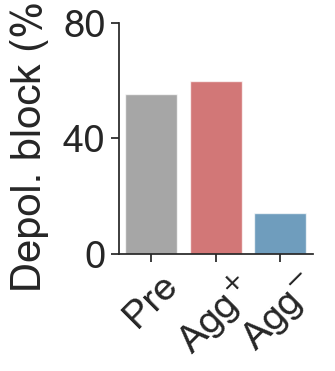

In [120]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-'], palette= triple, alpha = 0.7)

plt.ylabel('Depol. block (%)', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.xlabel('')
plt.ylim(top=60)
plt.yticks(np.arange(0, 81, 40))
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

Adaptive      no  yes  All
Gal_positive              
no             5    3    8
yes            3    5    8
All            8    8   16
0.25 0.6170750774519739 1


Text(0.5, 1.0, 'galanin_adaptive_prop')

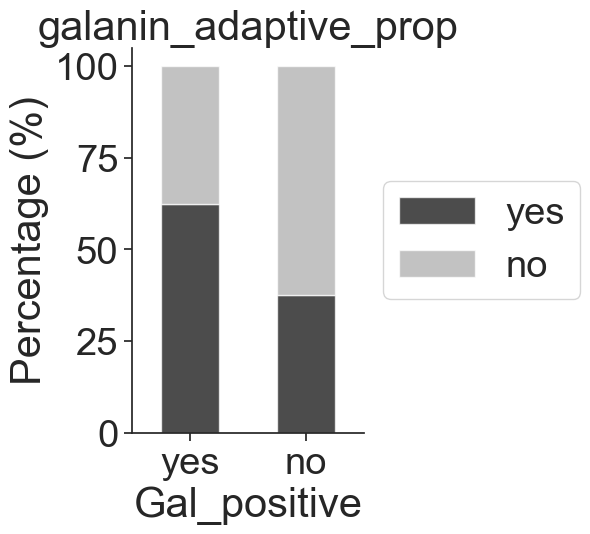

In [ ]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
# plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## Calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             14    0    5     0   19
Agg-              9    1   11     1   22
Pre              73    1   44     0  118
ZD7288            6    0    3     0    9
ZD7288_20         2    0    1     0    3
agrp_100         13    0    2     0   15
agrpkd           11    0    8     0   19
npy1r_antag       9    0    6     0   15
npy2r_antag       9    0    5     0   14
npy_10            7    1    2     0   10
npy_100           6    0    5     0   11
npy_antag        14    0    1     0   15
npykd            14    0    5     0   19
All             187    3   98     1  289
39.379493538755824 0.32113361470798685 36


Text(0.5, 1.0, 'CaT_prop')

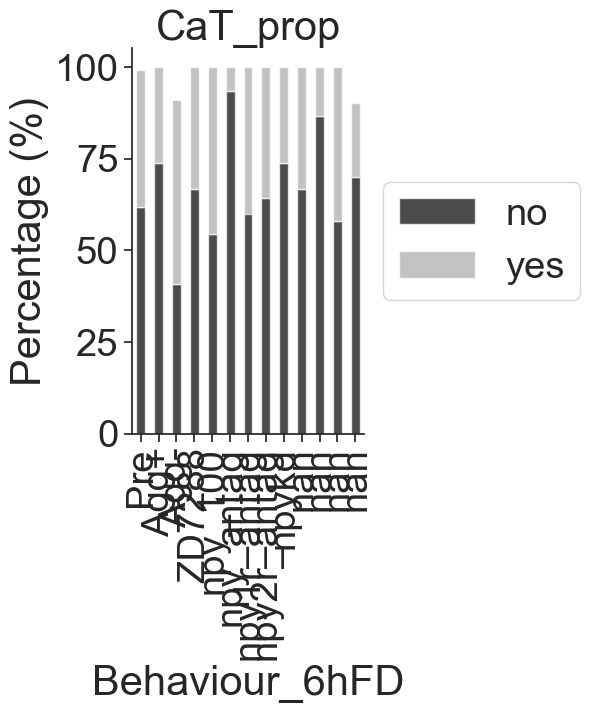

In [ ]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
# plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             4    6   10
yes            5    3    8
All            9    9   18
0.225 0.6352562959972483 1


Text(0.5, 1.0, 'galanin_CaT_prop')

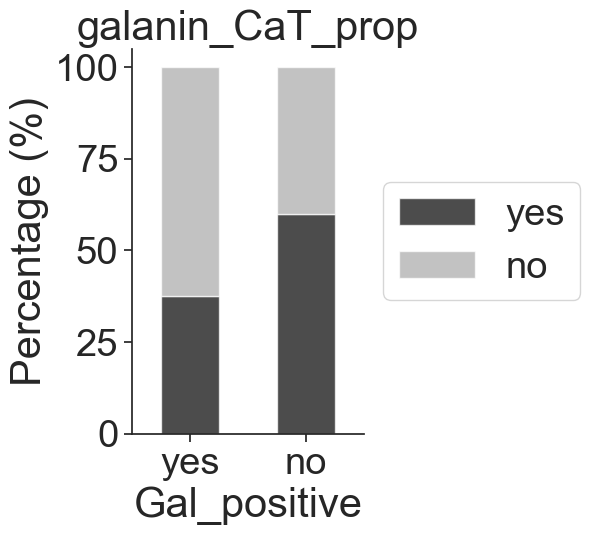

In [ ]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
# plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+             7   12   19
Agg-             1   21   22
Pre             32   86  118
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
agrpkd           1   18   19
npy1r_antag      4   11   15
npy2r_antag      2   12   14
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             82  215  297
61.17262675035552 7.299267647864261e-08 14


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'Pre'),
  Text(1, 0, 'Agg+'),
  Text(2, 0, 'Agg-'),
  Text(3, 0, 'ZD7288'),
  Text(4, 0, 'npy_100'),
  Text(5, 0, 'npy_antag'),
  Text(6, 0, 'npy1r_antag'),
  Text(7, 0, 'npy2r_antag'),
  Text(8, 0, 'npykd'),
  Text(9, 0, 'nan'),
  Text(10, 0, 'nan'),
  Text(11, 0, 'nan'),
  Text(12, 0, 'nan'),
  Text(13, 0, 'nan'),
  Text(14, 0, 'nan')])

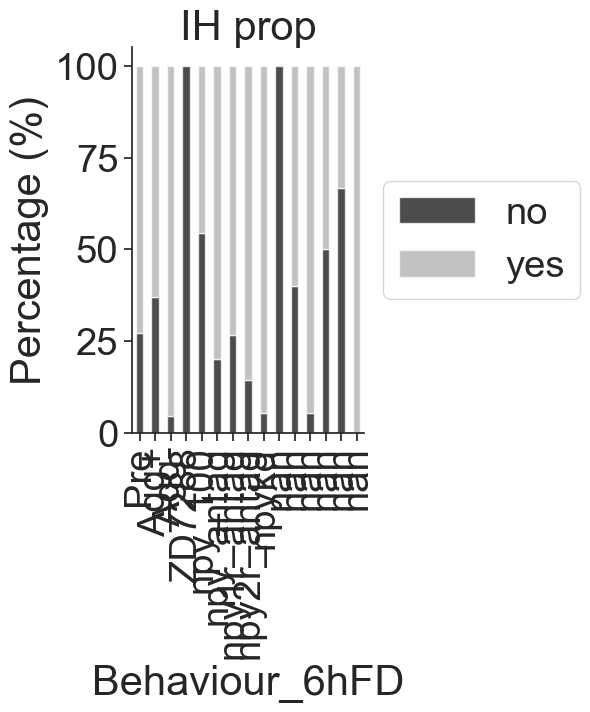

In [ ]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
# plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic               10   40   50
silent               38   59   97
silent                0    1    1
tonic                34  112  146
tonic                 0    3    3
All                  82  215  297
10.830621822532766 0.028535012181957323 4


Text(0.5, 0, '')

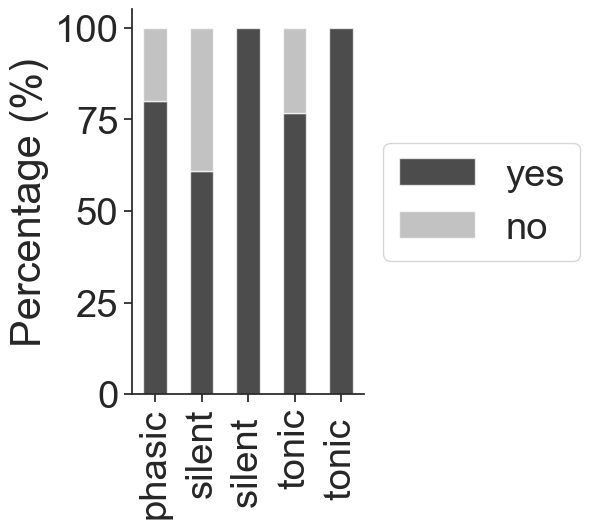

In [ ]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis (excitability)

In [5]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-', 'NPY 10nM', 'NPY 100nM', 'NPY Antag', 'NPY1R', 'NPY2R', 'NPY-KD', 'ZD7288']

ramp_path = 'ramps_all.csv'
import os
if os.path.exists(ramp_path):
    df_state = pd.read_csv(ramp_path)

else:
    # list all directory in filepath
    df_state = pd.DataFrame()

    for state in states:
        files = [file for file in glob(f'{path}/{state}/*.xlsx')]

        df_files = []
        for file in files:
            try:
                df_file = pd.read_excel(file)
                
            except ValueError:
                print(file, state + ' failed')
                continue
            df_file = df_file[(df_file['Event start ']!= 0) & (df_file['Event end '] != 0)]
            df_file['filename'] = file.split('/')[-1]
            df_file = df_file.dropna()
            
            df_files.append(df_file)

        df = pd.concat(df_files)
        df['state'] = state
        df_state = pd.concat([df_state, df])

    df_state.to_csv('ramps_all.csv', index = False)

    ephys = pd.read_csv('sampled_ephys_data.csv')
    
        

In [6]:
def process_df_state(df_state, states):
    # Rename the column
    df_state.rename(columns={'I_Injected(pA)': 'Injected'}, inplace=True)
    
    # Create and order the 'Injected' categorical column
    current_cat = np.arange(25, 175, 10)
    df_state['Injected'] = pd.Categorical(df_state['Injected'], current_cat).as_ordered()
    
    # Sort by 'Injected' and drop NaN values
    df_state.sort_values('Injected', inplace=True)
    df_state = df_state.dropna()
    
    # Create and order the 'state' categorical column
    df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()

    # Generate a DataFrame with all unique combinations of 'filename' and 'state'
    unique_combinations = df_state[['filename', 'state']].drop_duplicates()
    
    # Create a MultiIndex with all combinations of unique_combinations and current_cat
    all_combinations = unique_combinations.assign(dummy=1).merge(pd.DataFrame({'Injected': current_cat, 'dummy': 1}), on='dummy').drop('dummy', axis=1)
    
    # Merge with the original data to ensure all combinations are present
    df_state_full = all_combinations.merge(df_state, on=['filename', 'Injected', 'state'], how='left')
    # Calculate the number of spikes
    num_spike = df_state.groupby(by=['filename', 'Injected', 'state'])['Event start '].nunique().reset_index(name='num_spike')
    
    # Merge all combinations with num_spike to ensure all categories are present
    num_spike = all_combinations.merge(num_spike, on=['filename', 'Injected', 'state'], how='left').fillna({'num_spike': 0})
    
    # Get the first occurrence in each group and drop duplicates
    df_all = df_state_full.groupby(['filename', 'Injected', 'state']).first().reset_index().drop_duplicates()
    
    # Calculate the latency
    latency = df_state.groupby(['filename', 'Injected', 'state'])['Event start '].min().reset_index(name='latency_event_start')
    
    # Merge the calculated values into df_all
    df_all = pd.merge(df_all, num_spike, on=['filename', 'Injected','state'])
    df_all = pd.merge(df_all, latency, on=['filename', 'Injected','state'])
    df_all['latency'] = df_all['latency_event_start'] - df_all['Ramp_start']
    
    return df_all

df_all = process_df_state(df_state, states)


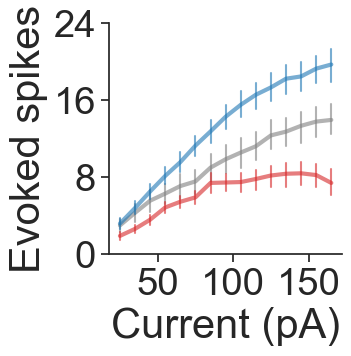

In [39]:
sns.set(font_scale=2.5) 
sns.set_style("ticks")

prop = 'num_spike'

plot_df = df_all[df_all.state.isin(['Pre', 'Agg+', 'Agg-'])]
fig, ax = plt.subplots(figsize = [3,3])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette, err_style="bars", ci=58,  
             linewidth=3, alpha=0.6)
# sns.boxplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")

ax.set_xlabel("Current (pA)")
plt.ylim(0,24)
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)
# plt.savefig('output_figures/latency_excitability.png',dpi = 300, bbox_inches = 'tight')

# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [26]:
df_state['filename'] = df_state['filename'].str.replace('.xlsx', '').str.upper()
estrous_df = process_df_state(df_state, ['Pre'])

ephys.rename(columns = {'experiment_day': 'filename'}, inplace = True)
ephys['filename'] = ephys['filename'].str.upper()
estrous_df =estrous_df[estrous_df.state == 'Pre'].merge(ephys[ephys['Behaviour_6hFD'] == 'Pre'].loc[:, ['filename', 'estrous_stage']], on = 'filename', how = 'left')
estrous_df.loc[estrous_df.estrous_stage == 'P<E', 'estrous_stage'] = 'E'
estrous_df.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)


In [27]:
estrous_df.estrous_stage.unique()

array(['P', 'M', 'E', 'VS to be stained ', nan, 'D'], dtype=object)

In [28]:
estrous_df[~estrous_df['estrous_stage'].isin(['P', 'M', 'E', 'D'])]['filename'].unique()


array(['S1C1 23112023', 'S1C1 27072023', 'S2C1 24072023'], dtype=object)

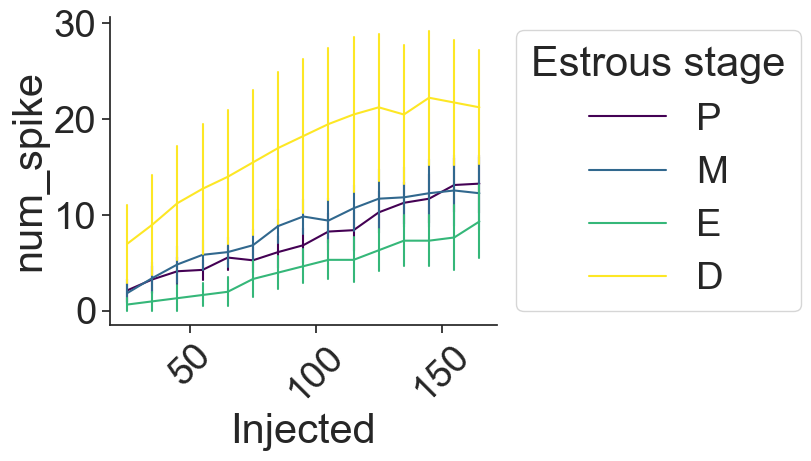

In [52]:
prop = 'num_spike'
estrous_df.loc[estrous_df.filename == 'S2C1 24072023', 'estrous_stage'] = 'E'
plot_df = estrous_df[(estrous_df.estrous_stage.isin(['P', 'E', 'M', 'D'])) & (estrous_df.state == 'Pre')]
fig, ax = plt.subplots(figsize = [5,4])

palette = plt.cm.viridis(np.linspace(0, 1, len(plot_df.estrous_stage.unique())))


sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'estrous_stage', palette=palette, err_style="bars", errorbar=("se", 1))
# sns.stripplot(data=plot_df, x="Injected", y=prop, hue = 'estrous_stage', palette=palette, dodge=True, size=5, alpha=0.5)



plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title = 'Estrous stage')
plt.xticks(rotation = 45)


sns.despine()



In [40]:
sub_df = df_all[df_all.state.isin(['Agg-', 'Agg+', 'Pre'])].dropna()
sub_df['state'] = sub_df['state'].astype('object')

# Two-way ANOVA
model = smf.ols('latency ~  Injected * C(state)', data=sub_df).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)


tukey = pairwise_tukeyhsd(sub_df['num_spike'], sub_df['state'] + sub_df['Injected'].astype(str))
print(tukey.summary())  



                         sum_sq     df          F        PR(>F)
Injected           5.562499e+06   14.0   9.911073  8.915265e-21
C(state)           1.045387e+06    2.0  13.038448  2.647241e-06
Injected:C(state)  4.038562e+05   28.0   0.359789  9.991836e-01
Residual           3.399516e+07  848.0        NaN           NaN
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
Agg+105 Agg+115   0.3333    1.0  -8.4512  9.1179  False
Agg+105 Agg+125   0.7143    1.0  -8.0703  9.4989  False
Agg+105 Agg+135   0.9048    1.0  -7.8798  9.6893  False
Agg+105 Agg+145   0.5519    1.0  -8.1322  9.2361  False
Agg+105 Agg+155   0.3701    1.0   -8.314  9.0543  False
Agg+105 Agg+165   0.2929    1.0  -8.6008  9.1866  False
Agg+105  Agg+25   -4.039    1.0 -14.6336  6.5556  False
Agg+105  Agg+35  -3.9905    1.0 -13.6135  5.6325  False
Agg+105  Agg+45  -3.4683    1.0 -12.6115   5.675  False
Agg+105 

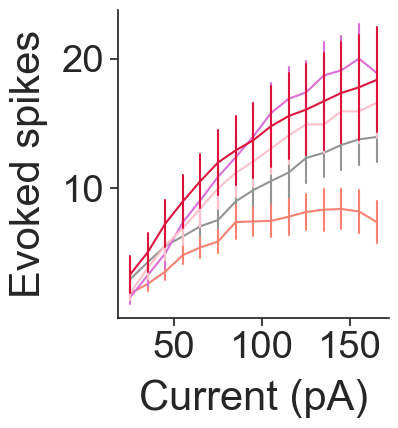

In [193]:
prop = 'num_spike'

# generate random number of colors
num_colors = len(df_all['state'].unique())
colors = sns.color_palette("tab10", num_colors)

plot_df = df_all[df_all.state.isin(['Agg+', 'NPY Antag', 'NPY1R', 'NPY2R',  'Pre'])]
fig, ax = plt.subplots(figsize = [3.5,4])

palette = ['#929591', 'salmon', 'black','black','black','orchid','pink','crimson','black','black']
sns.lineplot(data=plot_df, x="Injected", y=prop, hue = 'state', palette=palette, err_style="bars", errorbar=("se", 1))


# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend_.remove()

sns.despine()
plt.xlabel('Current (pA)', labelpad=10, fontsize=30)
plt.ylabel('Evoked spikes',labelpad=10,fontsize=30)
plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/{prop}_antag.pdf',dpi=300,bbox_inches='tight', transparent=True)

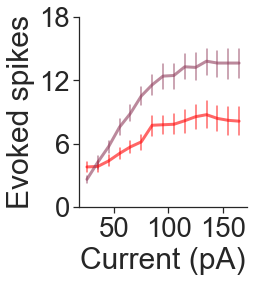

In [115]:
# only Agg+ and KD-Y

sns.set(font_scale=2.5) 
sns.set_style("ticks")

plot_df3 = df_all[df_all.state.isin(['Agg+', 'NPY-KD'])]
fig, ax = plt.subplots(figsize = [3,3.5])

typ = 'Agg+_KD'
colors = {'Pre': 'gray', 'Agg+': 'red', 'ZD7288': 'black', 'NPY-KD': '#8F3B5A', 
          'NPY Antag': 'lightcoral', 'NPY 10nM': 'orange', 'Agg-': 'blue'}
sns.lineplot(data=plot_df3, x="Injected", y=prop, hue = 'state', palette=colors, err_style="bars", ci=58, linewidth=3, alpha=0.6)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 6, 12, 18])
sns.despine(bottom=False)

plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [116]:
model = ols('num_spike ~ C(Injected) + C(state) + C(Injected):C(state)', data=plot_df3).fit()
result = sm.stats.anova_lm(model, type=2)
print(result)

                         df        sum_sq     mean_sq          F        PR(>F)
C(Injected)            14.0   3251.293345  232.235239   7.261325  7.069987e-14
C(state)                6.0   2041.680583  340.280097  10.639575  3.702339e-11
C(Injected):C(state)   84.0   1370.605541   16.316733   0.510177  9.998856e-01
Residual              516.0  16502.963887   31.982488        NaN           NaN


# Estrous cycle influence

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
?                         1       1      2    4
D                         5       9     18   32
E                         2       3      3    8
M                         4       9     16   29
P                         8       8     17   33
VS to be stained          0       0      1    1
no VS                     1       2      9   12
not taken                 1       2      1    4
All                      22      34     67  123
6.886380024675043 0.9390030547650252 14
I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
D                         2       5      3   10
E                         3       1      0    4
P                         1       3      2    6
All                       6       9      5   20
5.1000000000000005 0.27718991430409357 4


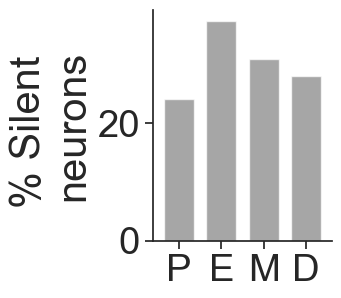

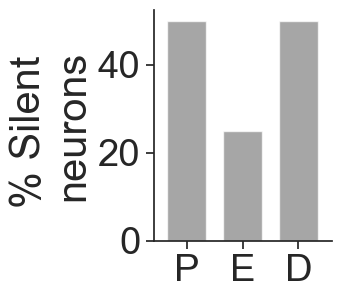

In [202]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')



ephys = ephys[ephys.I_zero_reclassified.isin(['silent', 'phasic', 'tonic'])] # was previously I_zero...
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero_reclassified', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            y = 'silent',
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['gray'],
            figsize = (2.3,3), alpha = 0.7, width = 0.7)
           
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('% Silent \nneurons')
    plt.xlabel('')
    ax.legend_.remove()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
#     plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')
    # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/silent_estrous_{state}.pdf',
    #             dpi=300,bbox_inches='tight', transparent=True)

0.9048018533563853 0.28003767501864335


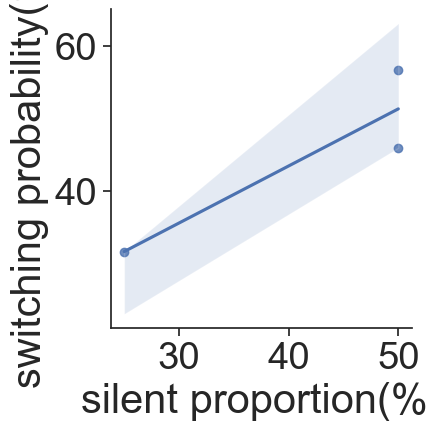

In [203]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

1.2361923955255694 0.3215637170184157 Cm(pF)
0.17439551597725453 0.9134891125098722 Firing_freq_(Hz)_I0
0.18079225994169298 0.9092071294008928 Instant_freq_(Hz)
1.1478860380692641 0.33379630978723623 isi_(ms)
1.2870229741220371 0.2840399555406233 CaT
4.367436306757196 0.0065018842603856725 Ih_at_-120mV
Ih_at_-120mV 0.0065018842603856725
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  -0.2498 0.9996  -6.7446   6.245  False
     D      M  -5.6905 0.0059 -10.1044 -1.2765   True
     D      P  -1.6846 0.7352   -5.989  2.6197  False
     E      M  -5.4406 0.1303 -11.9071  1.0258  False
     E      P  -1.4348 0.9355  -7.8269  4.9573  False
     M      P   4.0058 0.0732  -0.2556  8.2672  False
-----------------------------------------------------


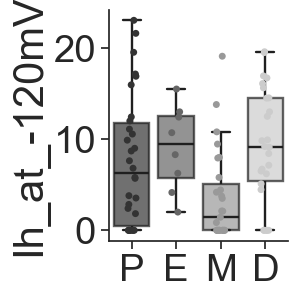

1.5897747188804296 0.2006916058116817 AP_ampl
1.5945869556244934 0.2000977034270794 AP_halfwidth
1.5256371043681023 0.21670127294122613 AP_time_to_peak
0.3898101206897316 0.7606129716222748 area(mV_ms)
0.43801429990433294 0.7265915464159713 rheobase_at_-60mV_(pA)
0.32795798291273337 0.8051375951258275 AHP_(mV)
0.2877241063615284 0.8341629053245254 Vm
1.1405870710967885 0.3372963622124458 Input_Resistance
1.9145283788517156 0.1441449594561283 sPSC_frequency
1.015443385555317 0.39718485603365616 sPSC_Amplitude(pA)
0.6052483219536171 0.616267628223264 sPSCs_Rise time
0.31145240807490443 0.8169338637018739 sPSCs (decay)
0.2 0.8886328452859166 AC-I0
nan nan AC_-60


In [204]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

sns.set(font_scale=2.5) 
sns.set_style("ticks")

for state in ['Pre']:  #change Pre/Post accordingly!
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        if 'AP' in column:
            state_df = state_df[state_df[column] > 0]

        
        try:
      
            stat, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
            print(stat,p, column)
        
            
            

            
            if p < 0.05:
                print(column , p)
                state_df = state_df.loc[:, ['estrous_stage', column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(endog=state_df[column],
                                         groups=state_df['estrous_stage'],
                                        alpha=0.05)
                print(multiple_comp_result.summary())

                fig,ax = plt.subplots(figsize = (2.3,3))
                
              
                sns.stripplot(x='estrous_stage', y =column, data= state_df, palette='gray', order=['P', 'E', 'M', 'D'])
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7),  order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
                sns.despine()
                # plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
                
            
            plt.show()
        except Exception:
            print(column)
            continue

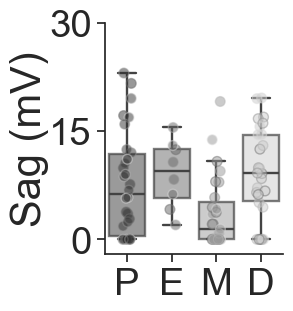

In [205]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = ['#707070', '#939393', '#B7B7B7', '#DBDBDB'], boxprops=dict(alpha=0.7))
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = state_df, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor=['#707070', '#939393', '#B7B7B7', '#DBDBDB'], palette = 'gray', alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

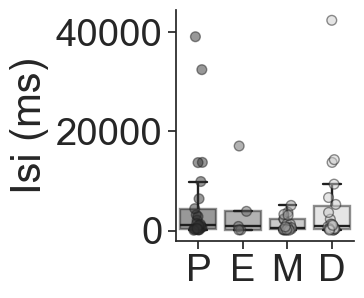

In [206]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")
param = 'isi_(ms)'

non_silent = state_df[state_df.I_zero_reclassified != 'silent']
# non_silent = state_df
ax = sns.boxplot(x='estrous_stage', y=param, data = non_silent, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray', boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='estrous_stage', y=param, data = non_silent, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('Isi (ms)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))


sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/{param}_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [207]:
group_counts = state_df['estrous_stage'].value_counts()
print(f"Cell numbers: \n{group_counts}")
unique_counts = state_df.groupby('estrous_stage')['ID_mouse'].nunique()
print(f"Mouse numbers: \n{unique_counts}")

Cell numbers: 
estrous_stage
P    33
D    32
M    29
E     8
Name: count, dtype: int64
Mouse numbers: 
estrous_stage
P    10
E     3
M     8
D     5
Name: ID_mouse, dtype: int64


IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   21   26
E                   0    8    8
M                  12   15   27
P                   8   22   30
VS to be stained    1    0    1
not taken           2    2    4
All                28   72  100
12.83831908831909 0.04567651962790427 6
IH estrous_stage         no         yes
4              P  26.666667   73.333333
2              E   0.000000  100.000000
3              M  44.444444   55.555556
1              D  19.230769   80.769231


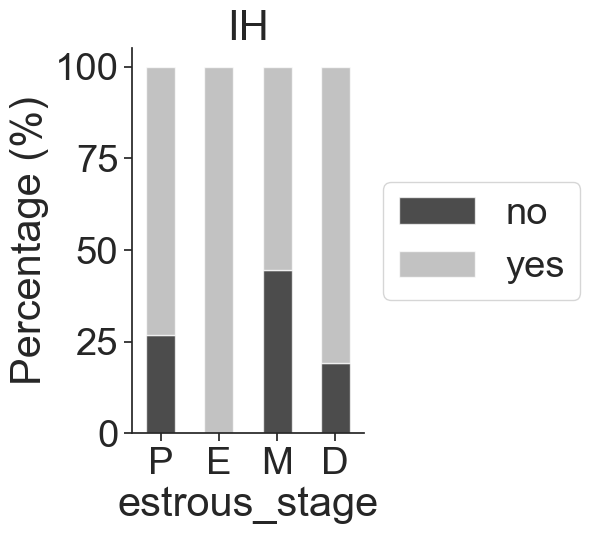

0.9943437438492674 0.00565625615073273
                            OLS Regression Results                            
Dep. Variable:                     no   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     9.458
Date:                Tue, 04 Feb 2025   Prob (F-statistic):            0.00236
Time:                        12:44:07   Log-Likelihood:                -941.72
No. Observations:                 228   AIC:                             1887.
Df Residuals:                     226   BIC:                             1894.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
I

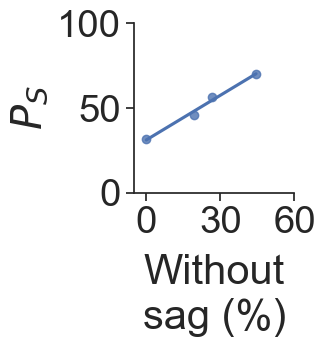

In [208]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']


raw = pd.read_csv('../NPS_behaviour_analysis/negative_parental_switch_summary.csv', encoding='cp1252')
raw = raw[(raw['estrous_stage'].isin(['P', 'E', 'M', 'D'])) &
         (raw['exp_cond'].isin(['all_stressor_5h', 'food_deprivation']))]
raw = raw.loc[:, ['estrous_stage', 'state_after']]
raw['state_after'] = raw['state_after'].apply(lambda x: 1 if x == 'Agg+' else 0)



for column in ['IH']: #cat_categ', 'IH', 'Adaptive'
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)


    stats_df = raw.merge(esprop, on = 'estrous_stage')
    response_var = 'state_after'
    formula = f'no ~ Q("{response_var}")'
    model = smf.ols(formula, data=stats_df).fit()
    print(model.summary())

    sns.set(font_scale=2.5)
    sns.set_style("ticks")
    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None, height=3.5, aspect=1) #plt.xlabel(r'$\mathit{P}_{\mathit{S}}$')
    plt.ylim([0, 100])
    plt.xlim([-5, 60])
    plt.xticks([0, 30, 60])
    plt.xlabel('Without\nsag (%)', labelpad=10)#plt.xlabel(f'% {column}')
    plt.ylabel(r'$\mathit{P}_{\mathit{S}}$') #plt.ylabel('Switching probability(%)')
#     plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/{column}_switching_corr.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)
    plt.show()

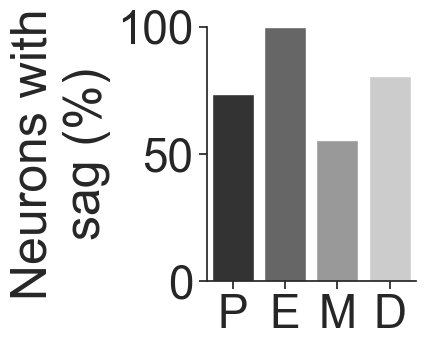

In [209]:
# Plot % of neurons that have Ih per estrous state
sns.set(rc={"figure.figsize": (2.7, 3.3)})
sns.set(font_scale=3) 
sns.set_style("ticks")
sns.barplot(x='estrous_stage', y='yes', data=esprop,  palette = 'gray')
plt.xlabel('')
plt.ylabel('Neurons with\nsag (%)')
plt.ylim(0, 100)
sns.despine(bottom=False)
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/percent_sag_estrous.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [210]:
from scipy.optimize import curve_fit

def func(x, a, b, c):
    return a * np.exp(-b * x) + c

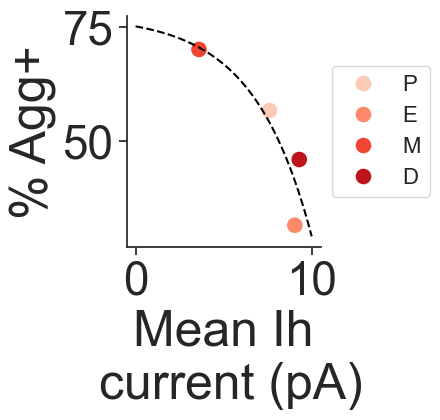

In [211]:
# mean of IH with estrous stage
mean_ih = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
grouped_df = pd.merge(mean_ih, estrous_df, on = 'estrous_stage')

x = grouped_df['Ih_at_-120mV']
y = grouped_df['switching probability']*100
popt, pcov = curve_fit(func, x, y)

plot_x = np.linspace(0, 10, 100)
plot_y = func(plot_x, *popt) /100


plt.subplots(figsize = (2.5, 3))
plt.plot(plot_x, plot_y, color = 'black', linestyle = '--')
sns.despine()



sns.scatterplot(x = 'Ih_at_-120mV', y = 'switching probability', hue = 'estrous_stage',data = grouped_df, 
                hue_order=  ['P', 'E', 'M', 'D'], palette = 'Reds', alpha = 1, s = 150 )
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize = 16)
plt.xlabel('Mean Ih\n current (pA)')
plt.ylabel('% Agg+')
plt.show()

In [212]:
residuals = y- func(x, *popt)
ss_res = np.sum(residuals**2)

ss_tot = np.sum((y-np.mean(y))**2)


r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.8018572719840595


### Corr btw Sag amplitude and %Agg+

In [213]:
from scipy.optimize import curve_fit

def func(x, a, b, c):
    return a * np.exp(-b * x) + c

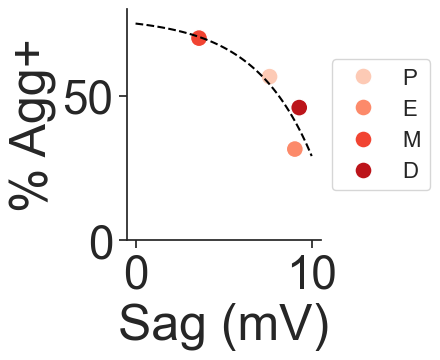

In [214]:
# mean of IH with estrous stage
mean_ih = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
grouped_df = pd.merge(mean_ih, estrous_df, on = 'estrous_stage')

x = grouped_df['Ih_at_-120mV']
y = grouped_df['switching probability']*100
popt, pcov = curve_fit(func, x, y)

plot_x = np.linspace(0, 10, 100)
plot_y = func(plot_x, *popt) /100


plt.subplots(figsize = (2.5, 3))
plt.plot(plot_x, plot_y, color = 'black', linestyle = '--')

sns.scatterplot(x = 'Ih_at_-120mV', y = 'switching probability', hue = 'estrous_stage',data = grouped_df, 
                hue_order=  ['P', 'E', 'M', 'D'], palette = 'Reds', alpha = 1, s = 150 )
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize = 16)
plt.xlabel('Sag (mV)')
plt.ylabel('% Agg+')
plt.ylim(0,80)
# plt.xlim(0,10)
sns.despine()
plt.show()

## Individual plots

### Pre

In [215]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

In [216]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 33 from 10 mice
Number of E neurons: 8 from 3 mice
Number of M neurons: 29 from 8 mice
Number of D neurons: 32 from 5 mice


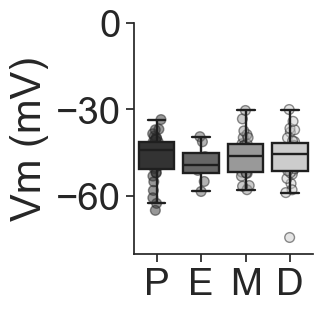

In [217]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

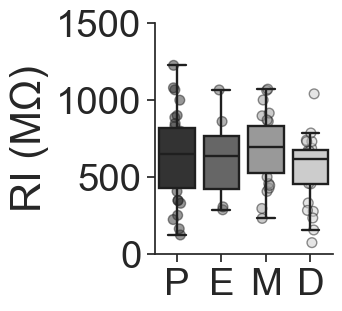

In [218]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

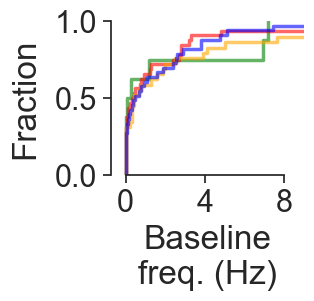

In [219]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [220]:
estrous_counts = ephys_estrous2['estrous_stage'].value_counts()
estrous_counts

estrous_stage
P    33
D    32
M    29
E     8
Name: count, dtype: int64

In [231]:
# stats - one-way ANOVA
ephys_estrous2.rename(columns = {'Firing_freq_(Hz)_I0': 'firing_freq'}, inplace = True)

model = smf.ols('firing_freq ~ estrous_stage', data=ephys_estrous2).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

# groups = ephys_estrous2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
# groups = [group for group in groups if len(group) > 0]
# anova_result = f_oneway(*groups)
# print("One-way ANOVA p-value:", anova_result.pvalue)

                   sum_sq    df         F    PR(>F)
estrous_stage    4.881853   3.0  0.174396  0.913489
Residual       914.437872  98.0       NaN       NaN


### Post (Agg+/- pooled)

In [86]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

In [87]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 25 from 4 mice
Number of D neurons: 13 from 3 mice


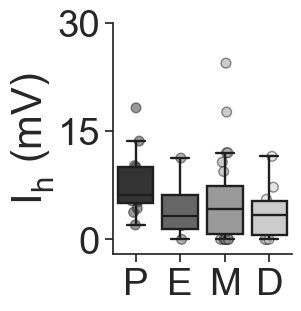

In [88]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=1)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ih_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

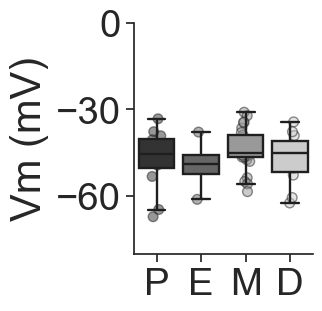

In [89]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Vm_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

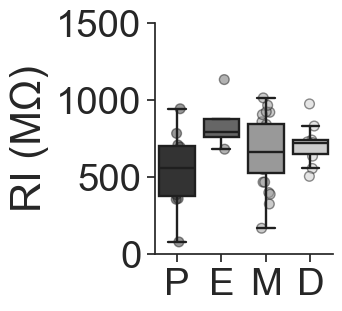

In [90]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/Ri_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

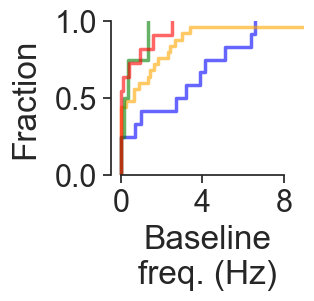

In [91]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/ff_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

In [148]:
# stats - one-way ANOVA
groups = ephys_post2.groupby('estrous_stage')['Firing_freq_(Hz)_I0'].apply(lambda x: x.dropna().tolist())
groups = [group for group in groups if len(group) > 0]
anova_result = f_oneway(*groups)
print("One-way ANOVA p-value:", anova_result.pvalue)

# Tukey HSD 
ephys_post3 = ephys_post2.dropna(subset=['Firing_freq_(Hz)_I0', 'estrous_stage'])
tukey_results = pairwise_tukeyhsd(ephys_post3['Firing_freq_(Hz)_I0'], ephys_post3['estrous_stage'])
print(tukey_results)

One-way ANOVA p-value: 0.02302615717756743
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     D      E   0.0408    1.0  -2.908 2.9896  False
     D      M   1.0803  0.601 -1.2787 3.4394  False
     D      P   2.3917 0.0375  0.1075 4.6758   True
     E      M   1.0395 0.7218 -1.6631 3.7421  False
     E      P   2.3508 0.0937 -0.2867 4.9883  False
     M      P   1.3113 0.2808 -0.6447 3.2674  False
---------------------------------------------------


# NPY administration

In [71]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')


In [72]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 128 from 24 mice
Number of NPY neurons: 11 from 4 mice


In [96]:
# ephys_npy

In [73]:
ephys_npy.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

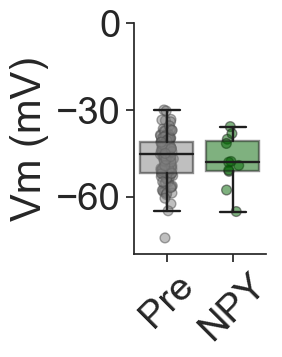

In [74]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

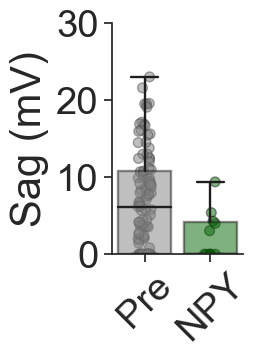

In [75]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)


    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

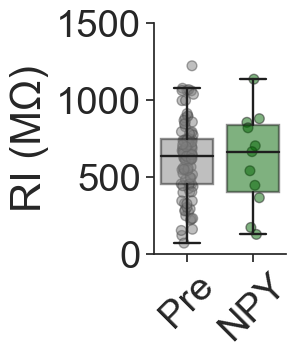

In [76]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [44]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy_100']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 19      28     58  105
npy_100              2       7      2   11
All                 21      35     60  116
0.027963756691906115


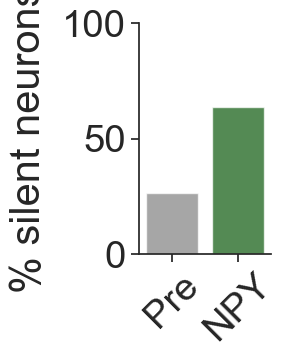

In [45]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy_100'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [46]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy_100')]

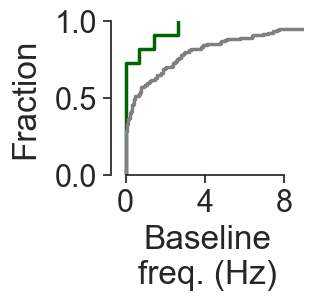

In [47]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [161]:
# stats U test
pre_ff = ephys_npy_ff[ephys_npy_ff['Behaviour_6hFD'] == 'Pre']['Firing_freq_(Hz)_I0'].dropna()
npy_ff = ephys_npy_ff[ephys_npy_ff['Behaviour_6hFD'] == 'npy_100']['Firing_freq_(Hz)_I0'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, npy_ff)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.02323222231920088


# AgRP administration

In [65]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace(['agrp_100_paired', 'agrp_100'], 'agrp')

In [62]:
# ephys_agrp.Behaviour_6hFD.unique()
# WE EXPECT 15 neurons from 5 mice

In [66]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 128 from 24 mice
Number of AgRP neurons: 15 from 5 mice


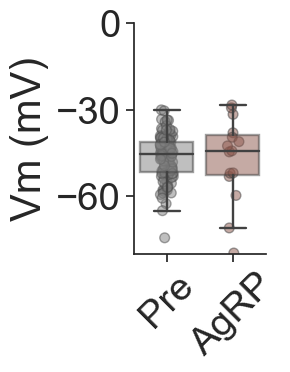

In [70]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

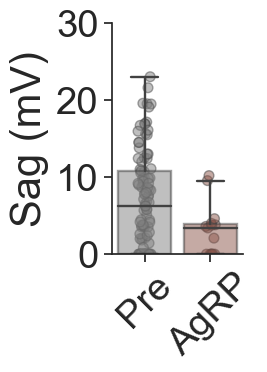

In [68]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Sag (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)


    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

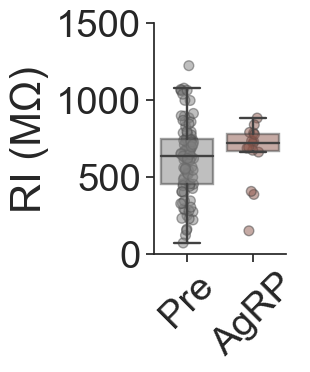

In [69]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp, boxprops=dict(alpha=0.5))
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [57]:
# stats U test
pre_ri = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['Input_Resistance'].dropna()
agrp_ri = ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp']['Input_Resistance'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ri, agrp_ri)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.2105021892393052


In [169]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 19      28     58  105
agrp                 2       5      8   15
All                 21      33     66  120
0.8224861593723192


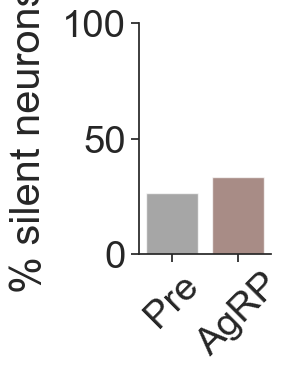

In [58]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('Silent neurons (%)', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [59]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp')]

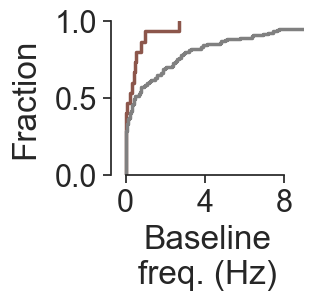

In [60]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [173]:
# stats U test
pre_ff = ephys_agrp_ff[ephys_agrp_ff['Behaviour_6hFD'] == 'Pre']['Firing_freq_(Hz)_I0'].dropna()
agrp_ff = ephys_agrp_ff[ephys_agrp_ff['Behaviour_6hFD'] == 'agrp']['Firing_freq_(Hz)_I0'].dropna()
u_statistic, p_value = mannwhitneyu(pre_ff, agrp_ff)
print("Mann-Whitney U test p-value:", p_value)

Mann-Whitney U test p-value: 0.08952854221309393
